# Project about the wealth of nations
The nations are: Italy, Spain, Germany, Sweden, United States, Canada, Brazil, Chile, South Africa and Nigeria

The project analyses the complex relationship between economic prosperity and the well-being of the population in certain countries around the world. The main objective is to understand how economic indicators are associated with key public health measures.

The data used in the project comes from the Python library 'wbgapi'.

In [1]:
# Import necessary libraries for all the project
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.animation import FuncAnimation

sns.set(style="whitegrid")

To view the data in the 'wbgapi' library, use the 'data_loader' code in the 'download data' folder.
The code generates seven different datasets relating to the seven indices used in these analyses.
Next, use the 'preprocessing' code to organise the data that will be used in the project.

In [2]:
# Import the data previously downloaded in CSV format
df1 = pd.read_csv('../data/gdp_per_capita_1995_2024.csv')
df2 = pd.read_csv('../data/gdp_1995_2024.csv')
df3 = pd.read_csv('../data/life_expectacy_1995_2023.csv')
df4 = pd.read_csv('../data/health_expenditure_2000_2022.csv')
df5 = pd.read_csv('../data/infant_mortality_1995_2023.csv')
df6 = pd.read_csv('../data/unemployment_1995_2024.csv')
df7 = pd.read_csv('../data/population_growth_1995_2024.csv')

In [3]:
print(df1.head())
print(df2.head())
print(df3.head())
print(df4.head())
print(df5.head())
print(df6.head())
print(df7.head())

     Year      BRA       CAN      CHL       DEU       ESP       ITA      NGA  \
0  YR1995  4756.75  20679.63  5081.47  31747.24  15460.91  20712.18  1271.62   
1  YR1996  5179.13  21296.97  5333.50  30599.79  16100.62  23122.93  1632.72   
2  YR1997  5299.40  21901.56  5741.96  27046.96  14722.37  21883.99  1720.28   
3  YR1998  5105.89  21024.59  5419.82  27395.94  15382.33  22365.18  1822.47   
4  YR1999  3493.57  22315.25  4933.56  26965.49  15707.95  22050.00   480.67   

        SWE       USA      ZAF  
0  30254.30  28690.88  3855.63  
1  33022.56  29967.71  3617.55  
2  30324.45  31459.13  3700.24  
3  30605.62  32853.67  3309.61  
4  30969.10  34515.38  3242.37  
     Year           BRA           CAN           CHL           DEU  \
0  YR1995  7.693331e+11  6.059611e+11  7.382043e+10  2.593053e+12   
1  YR1996  8.504264e+11  6.306080e+11  7.858410e+10  2.506577e+12   
2  YR1997  8.832062e+11  6.549870e+11  8.574142e+10  2.218791e+12   
3  YR1998  8.637108e+11  6.340000e+11  8.1990

The uploaded datasets have countries as columns and years as rows. 
The selected indices are: GDP per capita, GDP state, life expectancy, health expenditure, infant mortality, unemployment and population growth.
Data with missing values has already been removed from the previously uploaded data using the “preprocessing” code in the “download data” folder.

The first column has a label for the years consisting of “Y” and the year. This label could cause problems, so we format it.

In [4]:
def prepare_df(df, df0=None):
    """
    Prepare a DataFrame:
    - remove empty rows
    - extract the years from the first column and put them as an index
    - if a second dataset df0 is passed, keep only the rows (years) common to both
    """
    df = df.dropna(how='all')
    years = df.iloc[:, 0].astype(str).str.extract(r'(\d+)')[0].astype(int)
    df_data = df.iloc[:, 1:]
    df_data.index = years

    if df0 is not None:
        # Prepare df0 in the same way (only years as index)
        df0_clean = df0.dropna(how='all')
        years0 = df0_clean.iloc[:, 0].astype(str).str.extract(r'(\d+)')[0].astype(int)
        df0_data = df0_clean.iloc[:, 1:]
        df0_data.index = years0

        # Find the common years
        common_years = df_data.index.intersection(df0_data.index)

        # Keep only the years common to both
        df_data = df_data.loc[common_years]
        df0_data = df0_data.loc[common_years]

        return df_data, df0_data

    return df_data

With this function, the first column is transformed into indices for future analysis. In addition, since removing the values means that not all datasets have the same rows, if a second dataset is used in the analysis, only the common years will be taken.

In [5]:
# Final datasets
gdp_pc = prepare_df(df1)
gdp = prepare_df(df2)
life = prepare_df(df3)
health = prepare_df(df4)
infant_mort = prepare_df(df5)
unemp = prepare_df(df6)
pop = prepare_df(df7)

We now finally have the datasets ready that can be used for analyses, that will help us understand the correlation between the economy and quality of life in the selected countries.
Let's start with some general analyses:

In [6]:
print(gdp_pc.describe())

                BRA           CAN           CHL           DEU           ESP  \
count     30.000000     30.000000     30.000000     30.000000     30.000000   
mean    7645.716667  39677.181333  10752.587667  40085.535000  25831.533000   
std     3208.429905  12290.270554   4584.539336   9693.891584   6921.286086   
min     2855.940000  20679.630000   4430.850000  23878.360000  14722.370000   
25%     4897.307500  25278.715000   5500.355000  30970.135000  18213.807500   
50%     8325.600000  43566.015000  11658.045000  42448.575000  28401.515000   
75%     9885.547500  50110.797500  14792.352500  47562.845000  30644.660000   
max    13396.620000  56256.800000  17067.040000  55800.220000  35603.250000   

                ITA          NGA           SWE           USA          ZAF  
count     30.000000    30.000000     30.000000     30.000000    30.000000  
mean   31399.387000  1724.379333  46795.717000  50929.738000  5625.527333  
std     6629.523804   712.295685  11487.639566  15379.387001

Per capita GDP shows that the United States, Sweden, Germany and Canada are well above the sample average, while Italy and Spain are at intermediate levels. Brazil and Chile show lower values than advanced countries, and the lowest levels are recorded in South Africa and especially Nigeria.

In [7]:
print(gdp.describe())

                BRA           CAN           CHL           DEU           ESP  \
count  3.000000e+01  3.000000e+01  3.000000e+01  3.000000e+01  3.000000e+01   
mean   1.493942e+12  1.387890e+12  1.914216e+11  3.298375e+12  1.172443e+12   
std    6.905513e+11  5.283668e+11  9.445404e+10  8.072871e+11  3.697443e+11   
min    5.097953e+11  6.059611e+11  7.026405e+10  1.966381e+12  5.897398e+11   
25%    8.537475e+11  7.943722e+11  8.292786e+10  2.549300e+12  7.586945e+11   
50%    1.668822e+12  1.540492e+12  1.984729e+11  3.481929e+12  1.305769e+12   
75%    2.035617e+12  1.780926e+12  2.738719e+11  3.911314e+12  1.442784e+12   
max    2.616156e+12  2.241253e+12  3.355181e+11  4.659929e+12  1.722746e+12   

                ITA           NGA           SWE           USA           ZAF  
count  3.000000e+01  3.000000e+01  3.000000e+01  3.000000e+01  3.000000e+01  
mean   1.850129e+12  3.007223e+11  4.495094e+11  1.590816e+13  3.044786e+11  
std    4.175820e+11  1.552079e+11  1.300569e+11  5.875

However, a comparison of average GDP figures shows that the United States clearly dominates the group, followed at some distance by Germany, Italy, Brazil, Canada and Spain. Sweden and Nigeria have smaller economies, while South Africa and Chile have the lowest GDPs. 
Overall, the distribution highlights stark differences between the major advanced economies and emerging countries.

In [8]:
print(life.describe())

             BRA        CAN        CHL        DEU        ESP        ITA  \
count  29.000000  29.000000  29.000000  29.000000  29.000000  29.000000   
mean   72.581724  80.563793  78.583793  79.462759  81.240690  81.396897   
std     2.592728   1.303806   1.552156   1.482295   1.946106   1.629799   
min    67.700000  77.980000  75.300000  76.420000  77.980000  78.170000   
25%    70.400000  79.530000  77.840000  78.330000  79.570000  80.130000   
50%    73.110000  81.070000  78.880000  79.840000  81.480000  81.640000   
75%    74.820000  81.660000  79.550000  80.640000  83.130000  82.690000   
max    75.850000  82.160000  81.170000  81.290000  83.880000  83.700000   

             NGA        SWE        USA        ZAF  
count  29.000000  29.000000  29.000000  29.000000  
mean   50.277931  81.164138  77.642069  60.333448  
std     2.672275   1.395351   0.986326   4.126013  
min    45.830000  78.740000  75.620000  53.910000  
25%    48.020000  79.850000  76.840000  57.160000  
50%    51.08

The data show wide differences in life expectancy: Spain, Italy, Sweden and Canada have the highest average values, while Brazil, Chile, the United States and Germany are in the middle range. The lowest life expectancies are in South Africa and, above all, Nigeria, which remains far behind high-income countries.

In [9]:
print(health.describe())

               BRA          CAN          CHL          DEU          ESP  \
count    23.000000    23.000000    23.000000    23.000000    23.000000   
mean    689.642609  4392.716087   911.529565  4507.277826  2386.584348   
std     273.800126  1333.740811   420.777437  1183.857278   631.847650   
min     248.380000  1988.160000   319.530000  2344.410000  1005.280000   
25%     438.735000  3512.035000   530.705000  3628.125000  2152.285000   
50%     768.270000  4660.800000   984.450000  4674.920000  2606.280000   
75%     893.145000  5306.815000  1221.375000  5204.650000  2843.825000   
max    1043.350000  6483.380000  1576.690000  6638.210000  3144.110000   

               ITA         NGA          SWE           USA         ZAF  
count    23.000000   23.000000    23.000000     23.000000   23.000000  
mean   2814.846087   65.690000  4854.884348   8202.721739  469.452609  
std     563.758473   24.723213  1512.863584   2237.604577  139.596210  
min    1524.240000   17.160000  2155.850000  

The health expenditure shows significant differences between countries: the United States, Sweden, Germany, and Canada have the highest average values, followed by Italy and Spain. Brazil and Chile are at lower levels, while the lowest values are observed in Nigeria and South Africa, indicating a significant disparity in health investment between advanced and emerging economies.

In [10]:
print(infant_mort.describe())

             BRA        CAN        CHL        DEU        ESP        ITA  \
count  29.000000  29.000000  29.000000  29.000000  29.000000  29.000000   
mean   23.955172   5.789655   9.055172   4.551724   4.313793   4.372414   
std    10.190107   0.532745   1.828267   0.828346   1.141654   1.298872   
min    14.400000   5.100000   6.700000   3.700000   3.100000   2.800000   
25%    16.000000   5.300000   7.700000   3.900000   3.300000   3.400000   
50%    19.500000   5.800000   8.800000   4.300000   4.000000   4.100000   
75%    30.100000   6.200000   9.800000   5.100000   5.100000   5.100000   
max    47.700000   6.900000  13.100000   6.500000   6.900000   7.500000   

              NGA        SWE        USA        ZAF  
count   29.000000  29.000000  29.000000  29.000000  
mean   147.362069   3.355172   7.551724  54.713793  
std     30.384364   0.688988   0.920256  17.465634  
min    104.900000   2.500000   6.500000  34.100000  
25%    124.800000   2.800000   6.700000  36.800000  
50%   

Infant mortality varies considerably between countries: the lowest rates are found in Sweden, Germany, Italy, Spain and Canada, followed by the United States and Chile. Brazil and South Africa have significantly higher rates, while Nigeria has the most extreme rates, highlighting stark disparities in child health between advanced and emerging economies.

In [11]:
print(unemp.describe())

             BRA        CAN        CHL        DEU        ESP        ITA  \
count  30.000000  30.000000  30.000000  30.000000  30.000000  30.000000   
mean    9.731667   7.278000   8.421333   6.684333  16.130333   9.648000   
std     1.951357   1.177028   1.700778   2.667689   5.269511   1.985359   
min     6.750000   5.280000   4.700000   3.070000   8.230000   6.080000   
25%     8.097500   6.457500   7.265000   3.935000  11.307500   7.920000   
50%     9.555000   7.160000   8.355000   7.275000  15.365000   9.550000   
75%    11.062500   7.662500   9.662500   8.797500  20.490000  11.675000   
max    13.700000   9.660000  11.310000  11.190000  26.090000  12.680000   

             NGA        SWE        USA        ZAF  
count  30.000000  30.000000  30.000000  30.000000  
mean    4.049667   7.455333   5.576000  25.284333  
std     0.629743   1.330192   1.705158   3.675221  
min     2.990000   4.730000   3.640000  22.290000  
25%     3.752500   6.697500   4.397500  22.565000  
50%     3.86

Unemployment rates show significant differences: the lowest rates are recorded in Nigeria, the United States and Germany, while the highest are in Spain and South Africa. Brazil, Italy, Chile and Canada have intermediate levels, and Sweden also ranks in the upper-middle range compared to the group of countries considered.

In [12]:
print(pop.describe())

             BRA        CAN        CHL        DEU        ESP        ITA  \
count  30.000000  30.000000  30.000000  30.000000  30.000000  30.000000   
mean    0.954000   1.176000   1.075667   0.084667   0.702000   0.123333   
std     0.358883   0.526404   0.317660   0.468937   0.642331   0.364581   
min     0.360000   0.550000   0.440000  -1.850000  -0.360000  -0.700000   
25%     0.737500   0.955000   0.980000  -0.050000   0.372500  -0.025000   
50%     0.870000   1.050000   1.010000   0.130000   0.455000   0.050000   
75%     1.225000   1.125000   1.247500   0.285000   1.115000   0.387500   
max     1.540000   2.960000   1.790000   0.870000   1.850000   0.770000   

             NGA        SWE        USA        ZAF  
count  30.000000  30.000000  30.000000  30.000000  
mean    2.559667   0.618000   0.856667   1.248333  
std     0.254307   0.362362   0.238390   0.304269  
min     2.080000   0.060000   0.160000   0.650000  
25%     2.440000   0.340000   0.790000   1.012500  
50%     2.64

Population growth rates are highest in Nigeria, South Africa, Canada, Chile and Brazil, while the United States, Sweden, Spain, Italy and Germany have lower rates, indicating relatively stable or slowly growing populations.

An overview of the economic and social data for the countries considered reveals clear trends between advanced and emerging economies.
The United States, Sweden, Germany and Canada stand out for their high per capita GDP, high total GDP, strong investment in healthcare and low infant mortality, as well as low unemployment rates and stable populations.
Italy and Spain have intermediate values, with moderate incomes and healthcare expenditure and high life expectancy.
Brazil, Chile and South Africa rank lower in terms of income and health, with higher infant mortality and lower healthcare expenditure; South Africa also has high unemployment.
Nigeria stands out for its extremely low GDP, life expectancy and healthcare, but has the highest population growth, highlighting stark disparities with developed countries.
In general, the data show a clear gap between high-income and emerging countries, with marked differences in terms of economy, health and population well-being.

Now that we have a general idea of how countries are performing, we can move on to the actual analysis and understand how the indicators interact with each other.

## Time series analysis
To see how the most important selected indices vary over time, let's create a function that generates a graph.

In [22]:
# Function for graphs over time
def plot_indicator(df, title):
    """
    Graphs over time with smaller figure size
    """
    plt.figure(figsize=(7, 4))
    for paese in df.columns:
        plt.plot(df.index, df[paese], marker='o', label=paese)
    plt.xlabel('Year')
    plt.ylabel('Value')
    plt.title(title)
    plt.legend()
    plt.show()

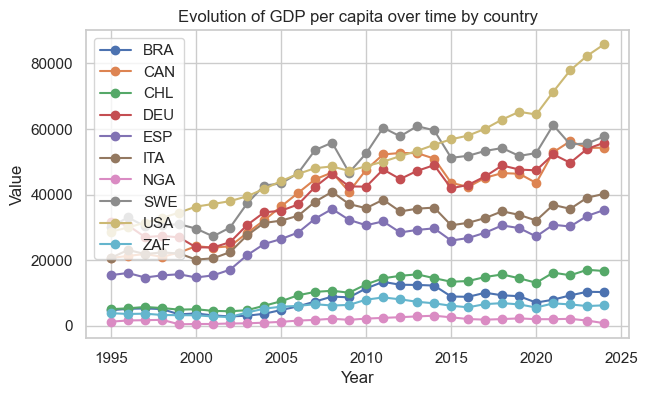

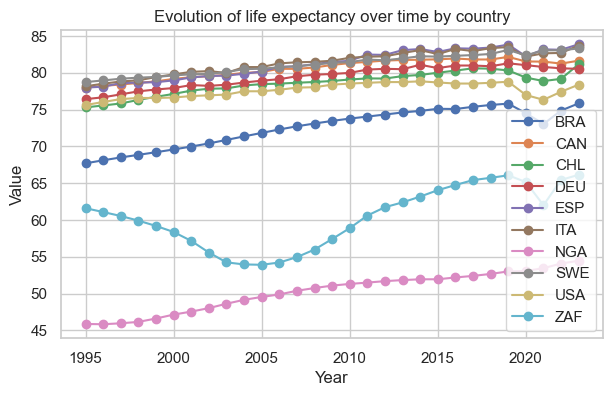

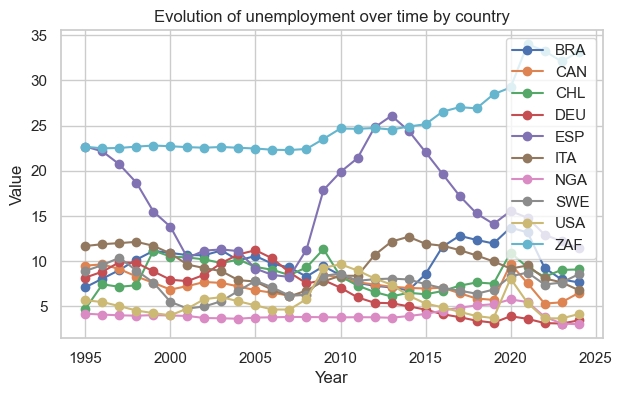

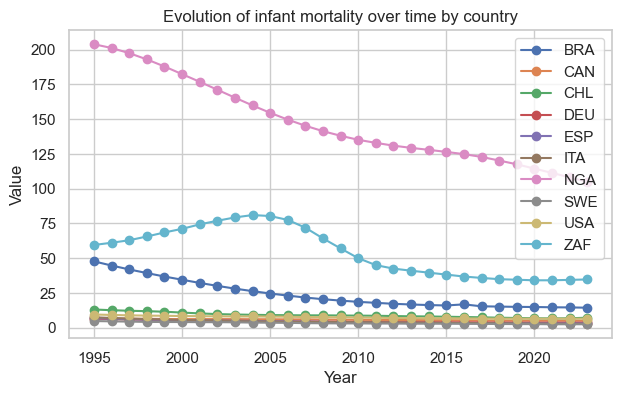

In [23]:
# Evolution over time by country
plot_indicator(gdp_pc, 'Evolution of GDP per capita over time by country')
plot_indicator(life, 'Evolution of life expectancy over time by country')
plot_indicator(unemp, 'Evolution of unemployment over time by country')
plot_indicator(infant_mort, 'Evolution of infant mortality over time by country')

These graphs show that per capita GDP has increased in almost all countries over the last 20 years, except in Nigeria and South Africa, where it has remained constant.
We also note the clear difference between life expectancy in all countries and in African countries, which, despite having increased in recent years, is still significantly lower than in other continents. For example, life expectancy in Nigeria is around 55 years, while in Italy it is almost 85 years.
As for the unemployment rate, the graph is not very clear, but we can see that the highest rate belongs to South Africa and that Spain has experienced significant variations over the years. The other countries all remain constant between 5 and 15 per cent.
As for infant mortality per 1,000 live births, we note that all countries are between 0 and 25 per thousand, except Nigeria and South Africa. In Nigeria, despite the rate having fallen by half, it still stands at 100 per thousand.

Now we want to see if there are any differences between before and after the 2008 economic crisis.
In fact, the 2008 economic crisis began in the United States due to risky defaults on home loans, causing major banks to fail. This led to recession, rising unemployment and economic hardship around the world.
To make this comparison, we will take two ranges of years: the first between 2000 and 2007, and the second between 2009 and 2019. We will stop at 2019 so as not to include the years of the global pandemic, another economic crisis event.

In [24]:
# Comparison of the situation before and after the 2008 economic crisis
def mean_pre_post(df):
    """
    Comparison by years
    """
    df.index = pd.to_numeric(df.index, errors='coerce')
    df_data = df.loc[(df.index >= 2000) & (df.index <= 2019)]
    pre = df_data.loc[(df_data.index >= 2000) & (df_data.index <= 2007)].mean()
    post = df_data.loc[(df_data.index >= 2009) & (df_data.index <= 2019)].mean()
    result = pd.DataFrame({
        'Mean 2000–2007': pre,
        'Mean 2009–2019': post
    })
    result['Δ % post/pre'] = (
    (result['Mean 2009–2019'] - result['Mean 2000–2007'])
    / result['Mean 2000–2007']
    * 100
    )
    return result.round(2)

In [28]:
gdp_per_capita_mean = mean_pre_post(gdp_pc)
life_expectancy_mean = mean_pre_post(life)
print("GDP per capita:")
print(gdp_per_capita_mean)
print("\nLife expectancy:")
print(life_expectancy_mean)


GDP per capita:
     Mean 2000–2007  Mean 2009–2019  Δ % post/pre
BRA         4340.60        10628.88        144.87
CAN        31793.04        47350.79         48.93
CHL         6510.85        14072.10        116.13
DEU        31623.04        45487.98         43.84
ESP        22649.28        29424.05         29.91
ITA        28195.45        34687.79         23.03
NGA         1022.28         2353.76        130.25
SWE        38797.45        54552.95         40.61
USA        41393.99        55363.55         33.75
ZAF         4567.88         7008.12         53.42

Life expectancy:
     Mean 2000–2007  Mean 2009–2019  Δ % post/pre
BRA           71.13           74.73          5.06
CAN           79.88           81.69          2.27
CHL           78.04           79.77          2.22
DEU           78.64           80.65          2.56
ESP           79.91           82.82          3.65
ITA           80.55           82.68          2.64
NGA           48.78           51.96          6.51
SWE           80

In [29]:
unemployment_mean = mean_pre_post(unemp)
infant_mortality_mean = mean_pre_post(infant_mort)
print("\nUnemployment:")
print(unemployment_mean)
print("\nInfant mortality:")
print(infant_mortality_mean)


Unemployment:
     Mean 2000–2007  Mean 2009–2019  Δ % post/pre
BRA           10.37            9.42         -9.10
CAN            6.98            7.07          1.25
CHL            9.72            7.39        -23.94
DEU            9.36            5.05        -46.01
ESP           10.44           20.25         94.00
ITA            8.37           10.48         25.22
NGA            3.76            4.22         12.15
SWE            6.06            7.55         24.74
USA            5.04            6.50         28.96
ZAF           22.51           25.56         13.52

Infant mortality:
     Mean 2000–2007  Mean 2009–2019  Δ % post/pre
BRA           27.58           16.78        -39.14
CAN            6.12            5.44        -11.24
CHL            9.60            8.01        -16.57
DEU            4.91            3.97        -19.13
ESP            4.91            3.47        -29.31
ITA            4.80            3.60        -25.00
NGA          163.09          127.80        -21.64
SWE            3

Looking at these data, we can see that after the 2008 crisis, per capita GDP grew significantly in emerging countries such as Brazil, Chile and Nigeria, while in developed countries the increase was more modest.
Life expectancy has increased in all countries, with particularly noticeable improvements in Nigeria and South Africa. Employment shows different scenarios: Germany and Chile have reduced unemployment, while Spain, Italy and the US have seen an increase.
Finally, infant mortality has decreased everywhere, with very sharp declines in South Africa and Brazil, highlighting progress in public health despite the economic crisis.

## Correlations between indicators
Now let's calculate the correlation between certain indicators to see how they influence each other. 
The correlations analysed are: GDP per capita and life expectancy, unemployment and life expectancy, GDP per capita and health expenditure, GDP per capita and infant mortality, and finally, health expenditure and infant mortality.

In [30]:
# Function to calculate correlations by country
def compute_country_correlations(df_x, df_y, name_x="X", name_y="Y"):
    """
    Total correlations
    """
    results = []
    for countries in df_x.columns.intersection(df_y.columns):
        x_vals = df_x[countries]
        y_vals = df_y[countries]
        valid_idx = x_vals.notna() & y_vals.notna()
        corr = x_vals[valid_idx].corr(y_vals[valid_idx]) if valid_idx.sum() > 1 else None
        results.append({
            'Country': countries,
            'X': name_x,
            'Y': name_y,
            'Pearson correlation': corr
        })
    return pd.DataFrame(results)

In [34]:
# Calculation of correlations
comparisons = [
    ("GDP per capita", gdp_pc, "Life expectancy", life),
    ("Unemployment", unemp, "Life expectancy", life)
]

corr_df_list = [compute_country_correlations(df_x, df_y, name_x, name_y)
                for name_x, df_x, name_y, df_y in comparisons]
corr_df = pd.concat(corr_df_list, ignore_index=True)
print(corr_df)

   Country               X                Y  Pearson correlation
0      BRA  GDP per capita  Life expectancy             0.788059
1      CAN  GDP per capita  Life expectancy             0.917633
2      CHL  GDP per capita  Life expectancy             0.853790
3      DEU  GDP per capita  Life expectancy             0.880574
4      ESP  GDP per capita  Life expectancy             0.820474
5      ITA  GDP per capita  Life expectancy             0.809786
6      NGA  GDP per capita  Life expectancy             0.628045
7      SWE  GDP per capita  Life expectancy             0.881360
8      USA  GDP per capita  Life expectancy             0.550046
9      ZAF  GDP per capita  Life expectancy             0.312325
10     BRA    Unemployment  Life expectancy             0.078653
11     CAN    Unemployment  Life expectancy            -0.532191
12     CHL    Unemployment  Life expectancy            -0.067191
13     DEU    Unemployment  Life expectancy            -0.795481
14     ESP    Unemploymen

Overall, the correlations paint a very consistent picture: GDP per capita, health and social conditions move together, but with varying intensity between countries. The relationship between GDP and life expectancy is almost always positive and strong in most countries, while it is weaker in the United States, Nigeria and South Africa, a sign that wealth alone does not always guarantee better health. Unemployment, on the other hand, has highly variable correlations: in some countries, higher unemployment is associated with lower life expectancy (such as Germany), while in others the relationship is weak or even positive, showing that the link is not direct and depends heavily on the economic and social context.

In [35]:
# Calculation of correlations
comparisons = [
    ("GDP per capita", gdp_pc, "Health expenditure", health),
    ("GDP per capita", gdp_pc, "Infant mortality", infant_mort)
]

corr_df_list = [compute_country_correlations(df_x, df_y, name_x, name_y)
                for name_x, df_x, name_y, df_y in comparisons]
corr_df = pd.concat(corr_df_list, ignore_index=True)
print(corr_df)

   Country               X                   Y  Pearson correlation
0      BRA  GDP per capita  Health expenditure             0.976388
1      CAN  GDP per capita  Health expenditure             0.960425
2      CHL  GDP per capita  Health expenditure             0.943708
3      DEU  GDP per capita  Health expenditure             0.966404
4      ESP  GDP per capita  Health expenditure             0.947983
5      ITA  GDP per capita  Health expenditure             0.980970
6      NGA  GDP per capita  Health expenditure             0.959392
7      SWE  GDP per capita  Health expenditure             0.932320
8      USA  GDP per capita  Health expenditure             0.987079
9      ZAF  GDP per capita  Health expenditure             0.968344
10     BRA  GDP per capita    Infant mortality            -0.719670
11     CAN  GDP per capita    Infant mortality            -0.866208
12     CHL  GDP per capita    Infant mortality            -0.853440
13     DEU  GDP per capita    Infant mortality  

The correlations between GDP and healthcare expenditure are extremely high everywhere, indicating that as wealth increases, investment in healthcare also increases systematically. 
The correlation between per capita GDP and infant mortality is very clear: it is always strongly negative in all countries.
In practice, the more rich a country is, the smaller is its infant mortality rate. This is true both for advanced economies (where the correlation is very strong, such as the US, Sweden or Germany) and for emerging economies, although somewhat less markedly so in Nigeria and South Africa.
This reflects an intuitive mechanism: with more economic resources, access to prenatal care, hospitals, hygiene and vaccinations increases, and this drastically reduces deaths in the first years of life.

In [36]:
# Calculation of correlations
comparisons = [
    ("Health expenditure", health, "Infant mortality", infant_mort)
]

corr_df_list = [compute_country_correlations(df_x, df_y, name_x, name_y)
                for name_x, df_x, name_y, df_y in comparisons]
corr_df = pd.concat(corr_df_list, ignore_index=True)
print(corr_df)

  Country                   X                 Y  Pearson correlation
0     BRA  Health expenditure  Infant mortality            -0.882394
1     CAN  Health expenditure  Infant mortality            -0.875274
2     CHL  Health expenditure  Infant mortality            -0.945332
3     DEU  Health expenditure  Infant mortality            -0.954965
4     ESP  Health expenditure  Infant mortality            -0.828613
5     ITA  Health expenditure  Infant mortality            -0.735665
6     NGA  Health expenditure  Infant mortality            -0.839138
7     SWE  Health expenditure  Infant mortality            -0.926105
8     USA  Health expenditure  Infant mortality            -0.950401
9     ZAF  Health expenditure  Infant mortality            -0.760831


Finally, the link between healthcare expenditure (or GDP) and infant mortality is strongly negative in all countries: more available resources and more investment in health are associated with a significant reduction in infant deaths.
In summary, indicators of wealth and healthcare expenditure show very stable relationships with health outcomes, while unemployment has a more irregular behaviour and is strongly influenced by the specific context of each country.

Now let's create a graph that clearly shows how the relationship between GDP per capita and life expectancy is not stable over time and how it varies greatly from country to country. 

In [32]:
# Function to calculate rolling correlation for all countries
def compute_rolling_correlation(df_x, df_y, window=15):
    """
    Correlation over time
    """
    rolling = pd.DataFrame(index=df_x.index)
    for countries in df_x.columns.intersection(df_y.columns):
        x = df_x[countries]
        y = df_y[countries]
        rolling[countries] = x.rolling(window=window, min_periods=3).corr(y)
    return rolling

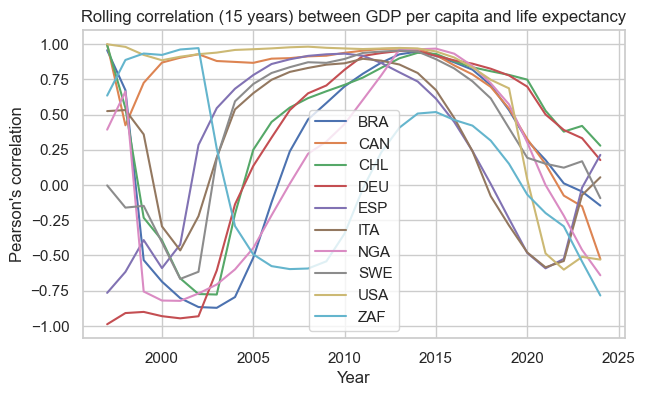

In [42]:
# Mobile correlation between GDP per capita and life expectancy
WINDOW = 15
rolling_corr = compute_rolling_correlation(gdp_pc, life, window=WINDOW)

# Mobile correlation plot
plt.figure(figsize=(7, 4))
for country in rolling_corr.columns:
    plt.plot(rolling_corr.index, rolling_corr[country], label=country)
plt.title(f"Rolling correlation ({WINDOW} years) between GDP per capita and life expectancy")
plt.xlabel("Year")
plt.ylabel("Pearson's correlation")
plt.legend()
plt.grid(True)
plt.show()

Looking at it as a whole, there is a noticeable ‘swing’ in the correlations: in the 1990s, many countries went through a period in which the link between economic growth and longevity seemed to weaken or even become negative. This is especially true for countries such as Brazil, Nigeria and South Africa, which show very marked declines: this means that during those fifteen years, GDP growth did not correspond to improvements in health, probably due to political crises, epidemics, inequalities or social instability.

As we approach the 2000s and especially the following decade, almost all curves rise and converge towards strongly positive correlations.

However, this phase of strong association does not last forever. After 2018–2020, a new general decline is observed, more or less pronounced depending on the country. The effect is visible almost everywhere, from Canada to South Africa, from the US to Italy. It is difficult not to link this decline to the COVID-19 pandemic: public health suddenly collapses while GDP moves in a different direction, and the historically positive relationship between the economy and longevity weakens or reverses.

In summary, the graph tells a complex story: the link between economic well-being and life expectancy is not fixed, but depends on political, social and health contexts. 

## Linear regressions on life expectancy using GDP per capita, health expenditure and infant mortality
We calculate the linear regression to see to what extent the variables GDP per capita, healthcare expenditure and infant mortality influence the variable life expectancy. 
The result consists of the regression coefficients and the regression scatter plot.

In [45]:
def regression_life_expectancy(pil_df, life_df, health_df, infant_mort_df):
    """
    Performs a linear regression on Life Expectancy using:
    - GDP per capita
    - Health Expenditure
    - Infant Mortality
    """

    # Find common countries and years (not necessary, but to be sure)
    countries = pil_df.columns.intersection(life_df.columns) \
                              .intersection(health_df.columns) \
                              .intersection(infant_mort_df.columns)

    common_years = pil_df.index.intersection(life_df.index) \
                               .intersection(health_df.index) \
                               .intersection(infant_mort_df.index)

    # Builds datasets with year-country rows
    data_rows = []
    for country in countries:
        df_country = pd.DataFrame({
            'Country': country,
            'Year': common_years,
            'GDP_per_capita': pil_df.loc[common_years, country],
            'Health_expenditure': health_df.loc[common_years, country],
            'Infant_mortality': infant_mort_df.loc[common_years, country],
            'Life_expectancy': life_df.loc[common_years, country]
        })
        data_rows.append(df_country)

    dataset = pd.concat(data_rows, ignore_index=True).dropna()

    # Linear regression
    x = dataset[['GDP_per_capita', 'Health_expenditure', 'Infant_mortality']]
    y = dataset['Life_expectancy']

    x = sm.add_constant(x)
    model = sm.OLS(y, x).fit()

    # Plot
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        x='GDP_per_capita',
        y='Life_expectancy',
        data=dataset,
        hue='Country',
        alpha=0.7
    )
    sns.regplot(
        x='GDP_per_capita',
        y='Life_expectancy',
        data=dataset,
        scatter=False,
        color='black'
    )

    plt.title('Relationship between GDP per capita and life expectancy')
    plt.xlabel('GDP per capita')
    plt.ylabel('Life expectancy')
    plt.grid(True)
    plt.show()

    return model, dataset

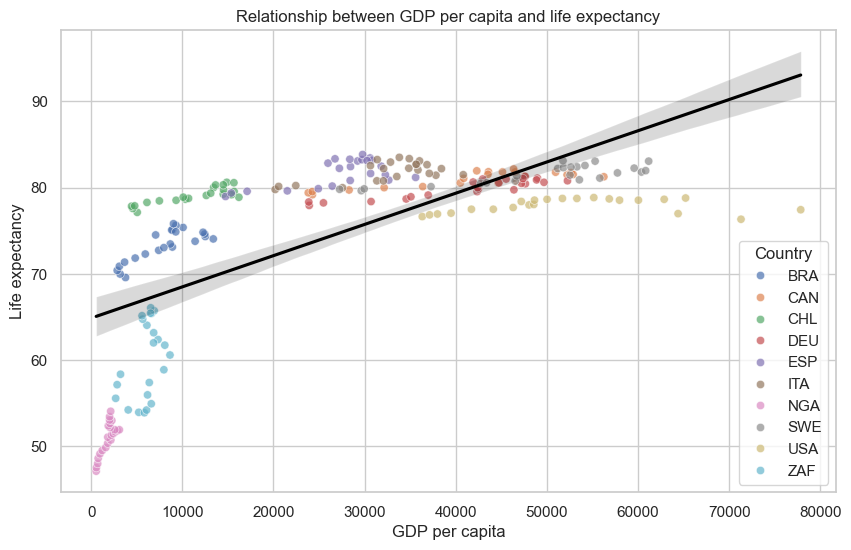

In [46]:
# Linear regression
model_df, data_df = regression_life_expectancy(gdp_pc, life, health, infant_mort)

The graph shows the ten countries represented by different colours. Here is a brief description of their trends:
- BRA (Brazil): low to medium GDP values with life expectancy around 70–75 years.
- CAN (Canada): a rich country with high GDP per capita and high life expectancy (around 82–84 years).
- CHL (Chile): average GDP and relatively high life expectancy, just below the richest countries.
- DEU (Germany): high GDP and stable life expectancy in the 80s.
- ESP (Spain): similar results to Germany, with a slightly higher life expectancy.
- ITA (Italy): high GDP and high life expectancy, in the range of 82–84 years.
- NGA (Nigeria): very low GDP and low life expectancy (around 50–55 years).
- SWE (Sweden): among the richest countries, with life expectancy consistently above 80 years.
- USA (United States): high GDP but slightly lower life expectancy than other rich countries (around 78–80 years).
- ZAF (South Africa): low-medium GDP and low life expectancy, around 55–65 years.

In summary, countries with higher GDP (Canada, Germany, Italy, Spain, Sweden, USA) have high life expectancies, while those with lower GDP (Nigeria, South Africa) have lower levels.

In [40]:
print(model_df.summary())

                            OLS Regression Results                            
Dep. Variable:        Life_expectancy   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                     993.2
Date:                Sun, 23 Nov 2025   Prob (F-statistic):          8.16e-130
Time:                        22:13:02   Log-Likelihood:                -557.14
No. Observations:                 230   AIC:                             1122.
Df Residuals:                     226   BIC:                             1136.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 75.8085      0

These results show that the model explains life expectancy very well (R² = 0.929), meaning that the three indicators included capture most of its variation. 
All coefficients are highly significant, but some signals should be interpreted with caution: per capita GDP has a very small but stable positive effect, while infant mortality has the strongest and most negative impact, confirming that it is one of the main determinants of life expectancy. 
On the other hand, the negative coefficient of health expenditure is surprising, probably due to multicollinearity (GDP and health expenditure are strongly correlated). 
In summary, the model works well, but the relationships between economic and health variables are so intertwined that some coefficients are distorted.